# California Housing Price Prediction Project

### 1. Load and Explore the California Housing Dataset

In [10]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing(as_frame=True)
df = housing.frame
df['median_house_value'] = housing.target * 100000

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [11]:
display(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDataFrame Description:")
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,342200.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   MedHouseVal         20640 non-null  float64
 9   median_house_value  20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB

DataFrame Description:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,206855.816909
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,115395.615874
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,14999.000000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,119600.000000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,179700.000000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,264725.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,500001.000000


### 2. Visualize Housing Prices on a Map

Let's create a scatter plot to visualize the housing locations and color them by `median_house_value` to understand the price distribution geographically.

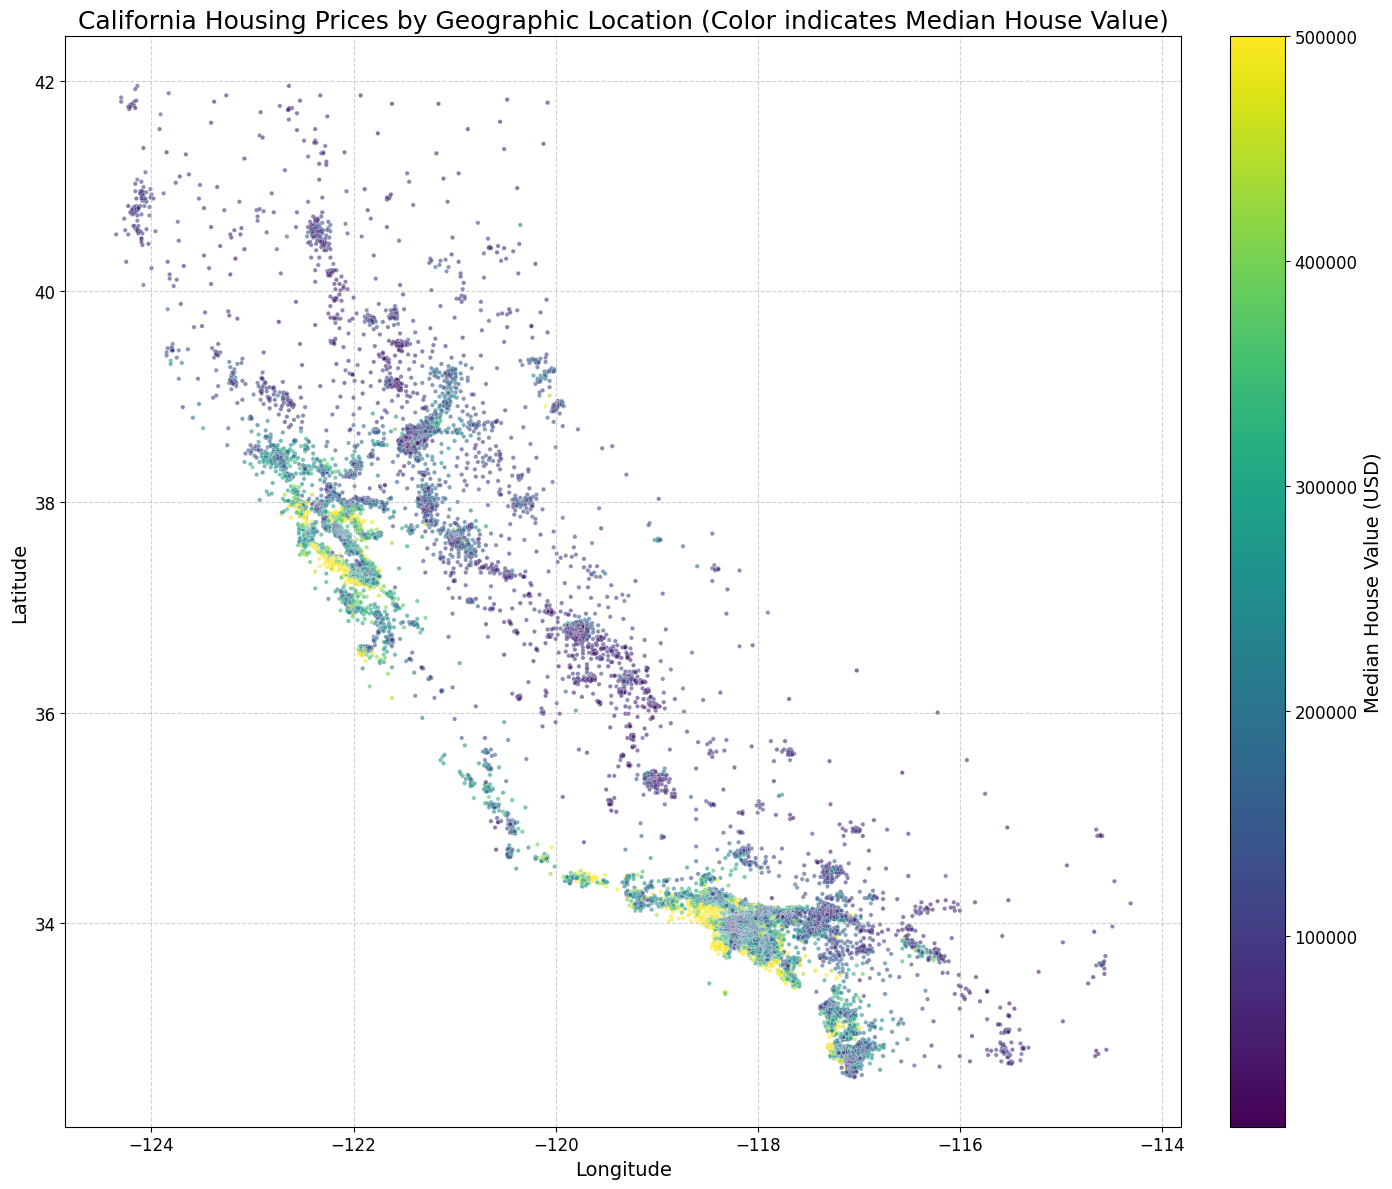

In [12]:
import matplotlib.cm as cm

plt.figure(figsize=(14, 12)) # Increased figure size for better presentation
sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='median_house_value',
    s=10, # Point size
    alpha=0.6, # Transparency to show density
    palette='viridis', # Perceptually uniform color palette
    legend=False # Remove default legend for custom colorbar
)

# Custom colorbar for median house value
norm = plt.Normalize(df['median_house_value'].min(), df['median_house_value'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Median House Value (USD)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.title('California Housing Prices by Geographic Location (Color indicates Median House Value)', fontsize=18)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Predicting Housing Prices 10 Years into the Future

To make this project even cooler, let's build a simple machine learning model to predict housing prices. We'll then simulate what these prices might look like 10 years from now by adjusting the `HouseAge` feature and comparing the current and predicted maps.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop(['MedHouseVal', 'median_house_value'], axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest Regressor model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model training complete!")

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance on Test Set:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared: {r2:.4f}")

Training the Random Forest Regressor model...
Model training complete!

Model Performance on Test Set:
Mean Absolute Error: $32,811.68
R-squared: 0.8038


### 4. Visualize Current vs. Predicted Housing Prices (10 Years Later)

Now, let's create a hypothetical scenario where all houses age by 10 years. We'll use our trained model to predict the `median_house_value` for this future state and display it alongside the current prices.

Predicting future housing prices...
Prediction complete!


/usr/local/lib/python3.12/dist-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/usr/local/lib/python3.12/dist-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/tmp/ipykernel_9001/2068271190.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


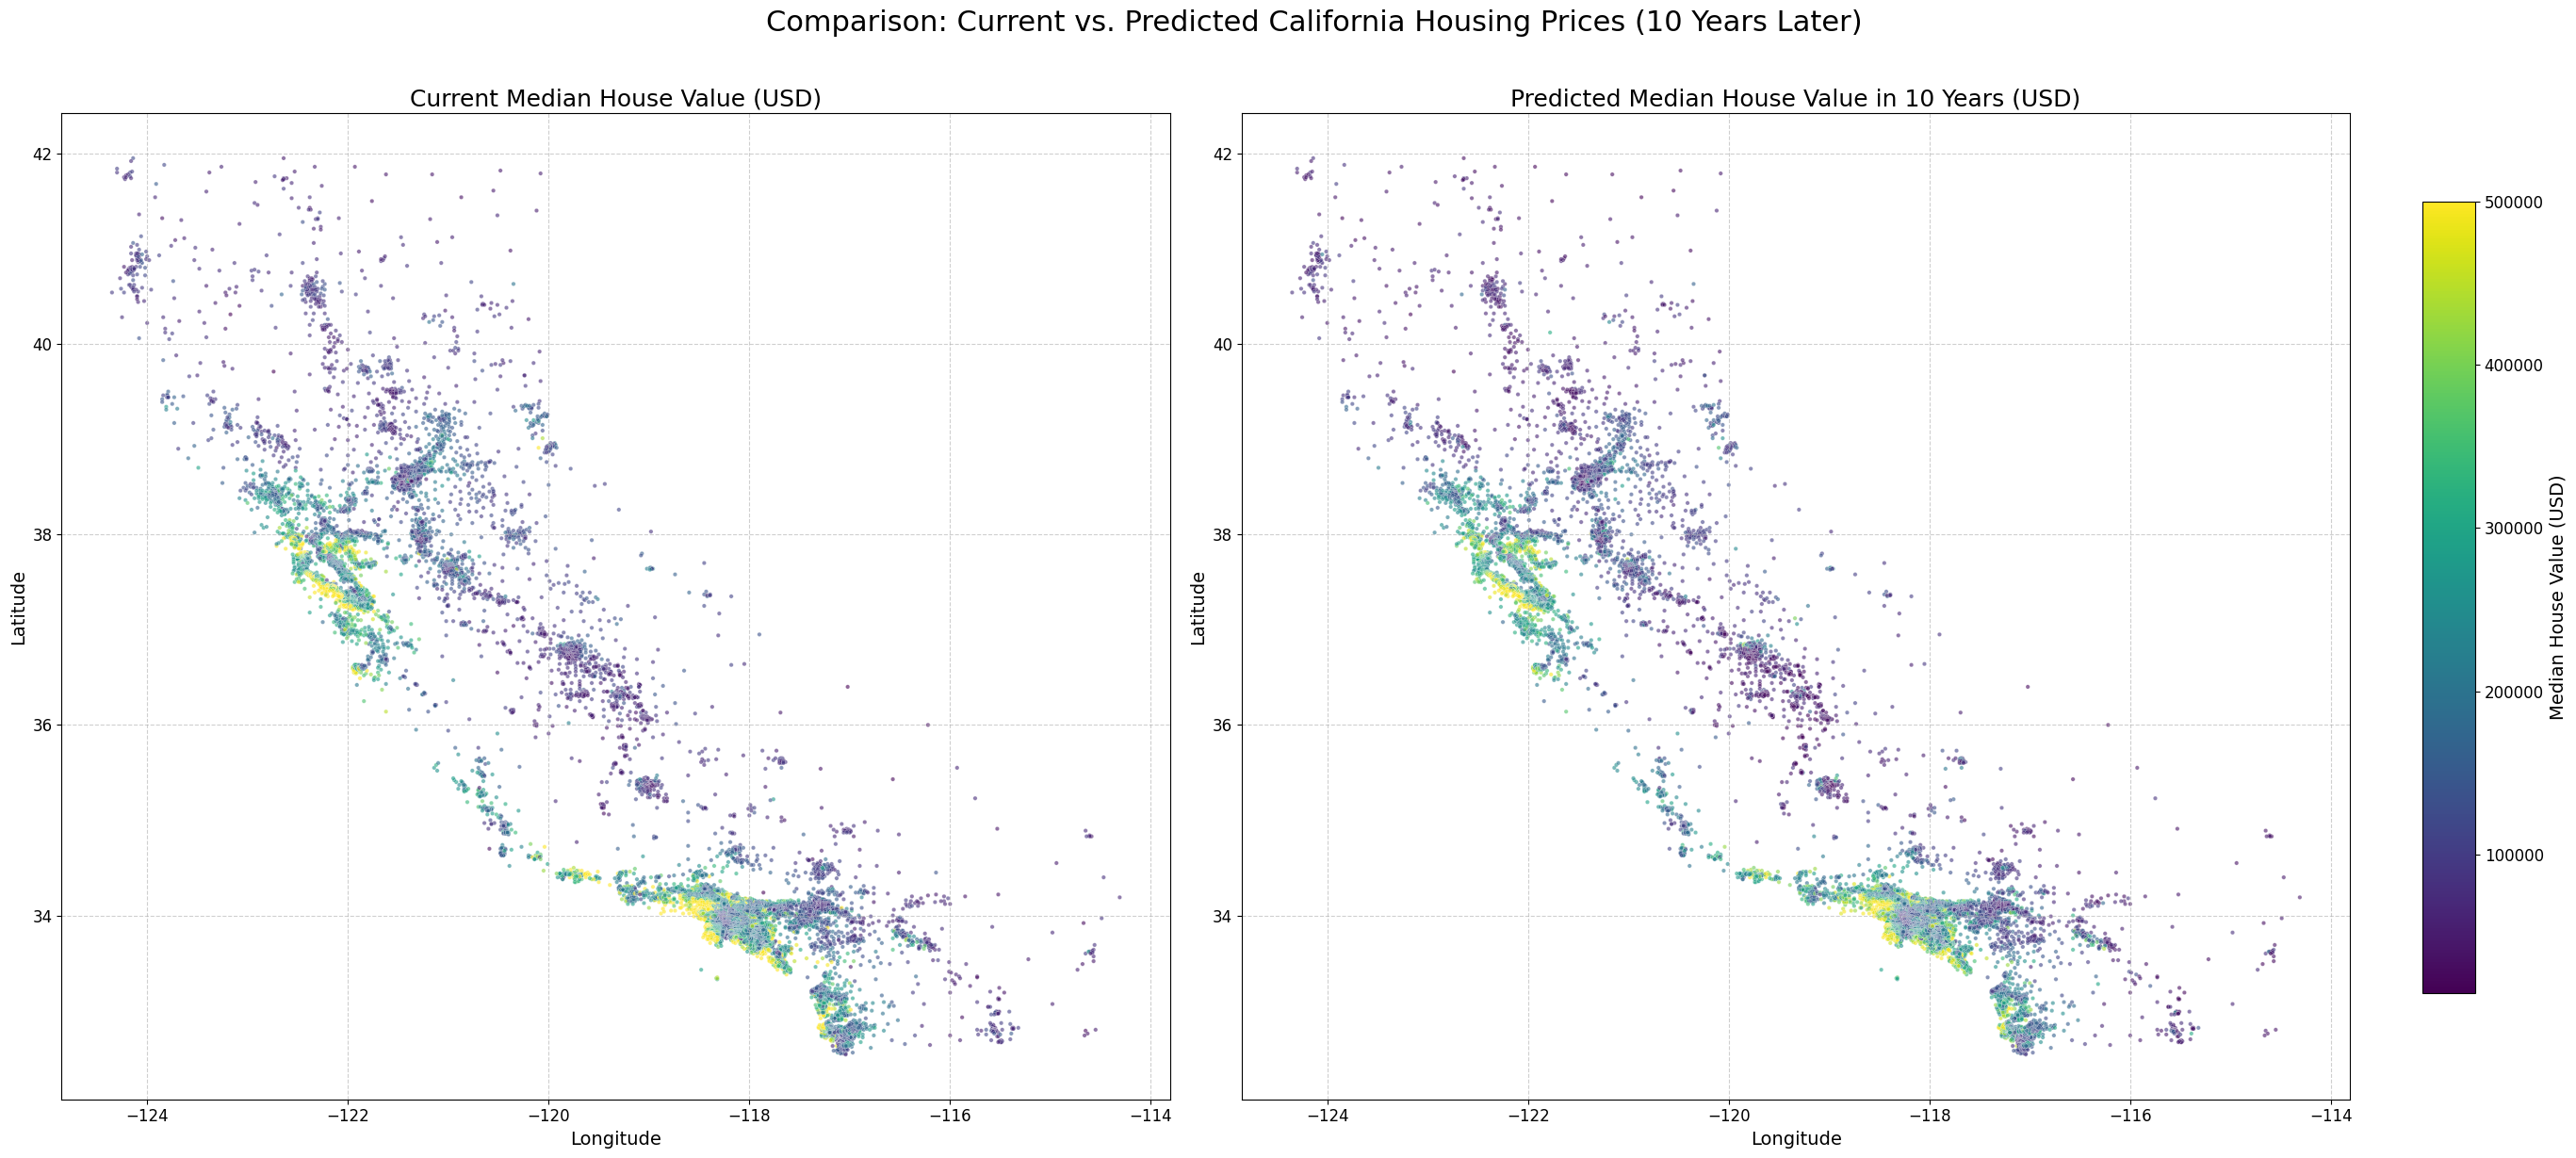

In [14]:
import numpy as np
import matplotlib.cm as cm

df_future = df.copy()
df_future['HouseAge'] = df_future['HouseAge'] + 10

X_future = df_future.drop(['MedHouseVal', 'median_house_value'], axis=1)

print("Predicting future housing prices...")
df_future['predicted_median_house_value'] = model.predict(X_future)
print("Prediction complete!")

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# Use combined min/max of current and predicted values for consistent colorbar
min_val = min(df['median_house_value'].min(), df_future['predicted_median_house_value'].min())
max_val = max(df['median_house_value'].max(), df_future['predicted_median_house_value'].max())
norm = plt.Normalize(min_val, max_val)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

# Plot 1: Current Housing Prices
sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='median_house_value',
    palette='viridis',
    s=10,
    alpha=0.6,
    legend=False,
    ax=axes[0],
    norm=norm
)
axes[0].set_title('Current Median House Value (USD)', fontsize=18)
axes[0].set_xlabel('Longitude', fontsize=14)
axes[0].set_ylabel('Latitude', fontsize=14)
axes[0].tick_params(labelsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Predicted Housing Prices (10 Years Later)
sns.scatterplot(
    data=df_future,
    x='Longitude',
    y='Latitude',
    hue='predicted_median_house_value',
    palette='viridis',
    s=10,
    alpha=0.6,
    legend=False,
    ax=axes[1],
    norm=norm
)
axes[1].set_title('Predicted Median House Value in 10 Years (USD)', fontsize=18)
axes[1].set_xlabel('Longitude', fontsize=14)
axes[1].set_ylabel('Latitude', fontsize=14)
axes[1].tick_params(labelsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Add a single colorbar for both subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Median House Value (USD)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.suptitle('Comparison: Current vs. Predicted California Housing Prices (10 Years Later)', fontsize=22, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()